# BloomNext: Early-Prediction of Harmful Algal Blooms
**CS 4262 - Foundations of Machine Learning, Vanderbilt University**

Trevor Xing-Xie, Nirmay Bhanderi, Connor Brugger

---

## 0. Setup

In [ ]:
! pip install pandas numpy matplotlib scikit-learn seaborn umap-learn

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
    make_scorer, mean_absolute_error, mean_squared_error
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Load and Clean HABSOS Data

Data downloaded from NCEI (https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0120767).  
Place `habsos_20240430.csv` in the same directory as this notebook.

In [ ]:
HABSOS_FILE = Path("data") / "habsos_20240430.csv"

raw = pd.read_csv(HABSOS_FILE)
print(f"Raw shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Raw shape: (211834, 28)
Columns: ['STATE_ID', 'DESCRIPTION', 'Unnamed: 2', 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_TIME', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'WIND_DIR', 'WIND_DIR_UNIT', 'WIND_DIR_QA', 'WIND_SPEED', 'WIND_SPEED_UNIT', 'WIND_SPEED_QA', 'OBJECTID', 'Unnamed: 27']


,STATE_ID,DESCRIPTION,Unnamed: 2,LATITUDE,LONGITUDE,SAMPLE_DATE,SAMPLE_TIME,SAMPLE_DEPTH,GENUS,SPECIES,...,WATER_TEMP_UNIT,WATER_TEMP_QA,WIND_DIR,WIND_DIR_UNIT,WIND_DIR_QA,WIND_SPEED,WIND_SPEED_UNIT,WIND_SPEED_QA,OBJECTID,Unnamed: 27
0,TX,Copano Bay 4,NaN,28.07237,-97.21968,2023/09/27,7:14,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134075,NaN
1,TX,Copano Bay 2,NaN,27.99567,-97.16831,2023/09/27,8:21,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134077,NaN
2,TX,Copano Bay 3,NaN,28.03930,-97.15836,2023/09/27,7:45,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134076,NaN
3,TX,Copano Bay 1,NaN,28.06491,-97.11270,2023/09/27,9:07,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134078,NaN
4,FL,off New Smyrna Beach; Atlantic,NaN,29.17460,-78.27890,1990/12/20,NaN,0.5,Karenia,brevis,...,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590299,NaN


In [4]:
# NCEI HABSOS columns:
# STATE_ID, DESCRIPTION (location name), empty col, LATITUDE, LONGITUDE,
# SAMPLE_DATE, SAMPLE_TIME, SAMPLE_DEPTH, GENUS, SPECIES, CATEGORY,
# CELLCOUNT, CELLCOUNT_UNIT, ..., WATER_TEMP, ...

# drop unnamed empty columns
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]
raw.columns = raw.columns.str.strip().str.upper()
print("Columns after cleanup:", list(raw.columns))

# rename to standard names
df = raw.rename(columns={
    'SAMPLE_DATE': 'date',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'CELLCOUNT': 'cellcount',
    'STATE_ID': 'state',
    'DESCRIPTION': 'location',
    'GENUS': 'genus',
    'SPECIES': 'species',
    'CATEGORY': 'category',
    'WATER_TEMP': 'water_temp',
    'SALINITY': 'salinity',
    'WIND_DIR': 'wind_dir',
    'WIND_SPEED': 'wind_speed'
})

print(f"\nTotal rows: {len(df)}")
print(f"States: {df['state'].unique()}")

# filter for Florida
df = df[df['state'] == 'FL']
print(f"After FL filter: {len(df)} rows")

# filter for Karenia brevis (genus=Karenia, species=brevis)
print(f"Genera present: {df['genus'].unique()[:10]}")
df = df[df['genus'].str.lower().str.strip() == 'karenia']
print(f"After Karenia filter: {len(df)} rows")

print(f"\nFiltered shape: {df.shape}")
df.head()

Columns after cleanup: ['STATE_ID', 'DESCRIPTION', 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_TIME', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'WIND_DIR', 'WIND_DIR_UNIT', 'WIND_DIR_QA', 'WIND_SPEED', 'WIND_SPEED_UNIT', 'WIND_SPEED_QA', 'OBJECTID']

Total rows: 211834
States: ['TX' 'FL' 'AL' 'MS']
After FL filter: 205168 rows
Genera present: ['Karenia']
After Karenia filter: 205168 rows

Filtered shape: (205168, 26)


,state,location,latitude,longitude,date,SAMPLE_TIME,SAMPLE_DEPTH,genus,species,category,...,water_temp,WATER_TEMP_UNIT,WATER_TEMP_QA,wind_dir,WIND_DIR_UNIT,WIND_DIR_QA,wind_speed,WIND_SPEED_UNIT,WIND_SPEED_QA,OBJECTID
4,FL,off New Smyrna Beach; Atlantic,29.1746,-78.2789,1990/12/20,NaN,0.5,Karenia,brevis,not observed,...,24.2,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590299
5,FL,off Daytona Beach; Atlantic,28.9822,-78.3590,1990/12/20,NaN,0.5,Karenia,brevis,very low,...,25.9,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590298
6,FL,off Daytona Beach; Atlantic,29.0000,-78.4700,1991/08/19,10:52,0.5,Karenia,brevis,not observed,...,30.0,deg. C,1,NaN,NaN,9,NaN,NaN,9,1644042
7,FL,off Cape Canaveral; Atlantic,28.5350,-78.5570,1990/12/20,NaN,0.5,Karenia,brevis,very low,...,24.0,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590297
8,FL,off Cape Canaveral; Atlantic,28.1060,-78.8310,1990/12/21,NaN,0.5,Karenia,brevis,not observed,...,24.9,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590306


In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y/%m/%d', errors='coerce')
df['cellcount'] = pd.to_numeric(df['cellcount'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['water_temp'] = pd.to_numeric(df['water_temp'], errors='coerce')
df['salinity'] = pd.to_numeric(df['salinity'], errors='coerce')
df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

before = len(df)
df = df.dropna(subset=['date', 'latitude', 'longitude', 'cellcount'])
df = df[df['cellcount'] >= 0].copy()
print(f"Dropped {before - len(df)} rows with missing/invalid values")

print(f"Cleaned shape: {df.shape}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Cell count range: {df['cellcount'].min():.0f} to {df['cellcount'].max():.0f}")
print(f"Cell count median: {df['cellcount'].median():.0f}")
print(f"Water temp available: {df['water_temp'].notna().sum()} / {len(df)} ({100*df['water_temp'].notna().mean():.1f}%)")
print(f"Salinity available: {df['salinity'].notna().sum()} / {len(df)} ({100*df['salinity'].notna().mean():.1f}%)")
print(f"Wind speed available: {df['wind_speed'].notna().sum()} / {len(df)} ({100*df['wind_speed'].notna().mean():.1f}%)")
print(f"Unique years: {sorted(df['date'].dt.year.unique())}")

Dropped 0 rows with missing/invalid values
Cleaned shape: (205168, 26)
Date range: 1953-08-19 to 2024-03-25
Cell count range: 0 to 388400000
Cell count median: 0
Water temp available: 102272 / 205168 (49.8%)
Salinity available: 103421 / 205168 (50.4%)
Wind speed available: 0 / 205168 (0.0%)
Unique years: [np.int32(1953), np.int32(1954), np.int32(1955), np.int32(1956), np.int32(1957), np.int32(1958), np.int32(1959), np.int32(1960), np.int32(1961), np.int32(1962), np.int32(1963), np.int32(1964), np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1968), np.int32(1969), np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.in

## 2. Spatial Binning and Weekly Aggregation

In [6]:
GRID_SIZE = 0.25  # degrees (~25km)
BLOOM_THRESHOLD = 100000  # cells/L, standard K. brevis bloom threshold

df['lat_bin'] = (df['latitude'] / GRID_SIZE).round() * GRID_SIZE
df['lon_bin'] = (df['longitude'] / GRID_SIZE).round() * GRID_SIZE
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)
df['week'] = df['date'].dt.to_period('W')

# safe log: log(1 + cellcount)
df['log_cellcount'] = np.log1p(df['cellcount'])

print(f"Unique grid cells: {df['grid_cell'].nunique()}")
print(f"Unique weeks: {df['week'].nunique()}")
print(f"Bloom samples (>= {BLOOM_THRESHOLD}): {(df['cellcount'] >= BLOOM_THRESHOLD).sum()} / {len(df)}")

Unique grid cells: 498
Unique weeks: 2744
Bloom samples (>= 100000): 14281 / 205168


In [7]:
weekly = df.groupby(['grid_cell', 'week', 'lat_bin', 'lon_bin']).agg(
    max_cellcount=('cellcount', 'max'),
    mean_cellcount=('cellcount', 'mean'),
    max_log=('log_cellcount', 'max'),
    mean_log=('log_cellcount', 'mean'),
    n_samples=('cellcount', 'count'),
    mean_water_temp=('water_temp', 'mean'),
    mean_salinity=('salinity', 'mean'),
    mean_wind_speed=('wind_speed', 'mean')
).reset_index()

weekly['bloom'] = (weekly['max_cellcount'] >= BLOOM_THRESHOLD).astype(int)
weekly['week_start'] = weekly['week'].apply(lambda w: w.start_time)
weekly = weekly.sort_values(['grid_cell', 'week_start']).reset_index(drop=True)

print(f"Weekly aggregated rows: {len(weekly)}")
print(f"Bloom weeks: {weekly['bloom'].sum()} / {len(weekly)} ({100*weekly['bloom'].mean():.1f}%)")

Weekly aggregated rows: 53998
Bloom weeks: 3959 / 53998 (7.3%)


## 3. Feature Engineering

In [8]:
# For each grid cell, create lagged features and the BloomNext target
records = []

for cell, grp in weekly.groupby('grid_cell'):
    grp = grp.sort_values('week_start').reset_index(drop=True)
    for i in range(4, len(grp) - 1):  # need 4 weeks of history + 1 week ahead
        row = {}
        row['grid_cell'] = cell
        row['lat_bin'] = grp.loc[i, 'lat_bin']
        row['lon_bin'] = grp.loc[i, 'lon_bin']
        row['week_start'] = grp.loc[i, 'week_start']
        row['year'] = grp.loc[i, 'week_start'].year

        # current week features
        row['max_log_curr'] = grp.loc[i, 'max_log']
        row['mean_log_curr'] = grp.loc[i, 'mean_log']
        row['bloom_curr'] = grp.loc[i, 'bloom']

        # previous week features
        row['max_log_prev1'] = grp.loc[i-1, 'max_log']
        row['bloom_prev1'] = grp.loc[i-1, 'bloom']

        # rolling 4-week features
        window = grp.loc[i-3:i]
        row['max_log_4wk'] = window['max_log'].max()
        row['mean_log_4wk'] = window['mean_log'].mean()
        row['bloom_count_4wk'] = window['bloom'].sum()

        # delta features
        row['log_diff'] = grp.loc[i, 'max_log'] - grp.loc[i-1, 'max_log']

        # environmental features
        row['water_temp'] = grp.loc[i, 'mean_water_temp']
        row['salinity'] = grp.loc[i, 'mean_salinity']
        row['wind_speed'] = grp.loc[i, 'mean_wind_speed']

        # seasonality (sin/cos encoding of month)
        month = grp.loc[i, 'week_start'].month
        row['month_sin'] = np.sin(2 * np.pi * month / 12)
        row['month_cos'] = np.cos(2 * np.pi * month / 12)

        # TARGET: bloom next week
        row['BloomNext'] = grp.loc[i+1, 'bloom']

        records.append(row)

feat_df = pd.DataFrame(records)

# --- Spatial neighbor features ---
# For each (grid_cell, week_start), check if any adjacent cell had a bloom
# Build a lookup of (week_start) -> set of blooming grid cells
bloom_lookup = feat_df[feat_df['bloom_curr'] == 1].groupby('week_start')['grid_cell'].apply(set).to_dict()

def count_neighbor_blooms(row):
    lat, lon, ws = row['lat_bin'], row['lon_bin'], row['week_start']
    blooming = bloom_lookup.get(ws, set())
    count = 0
    for dlat in [-GRID_SIZE, 0, GRID_SIZE]:
        for dlon in [-GRID_SIZE, 0, GRID_SIZE]:
            if dlat == 0 and dlon == 0:
                continue
            neighbor = f"{lat+dlat}_{lon+dlon}"
            if neighbor in blooming:
                count += 1
    return count

feat_df['neighbor_blooms'] = feat_df.apply(count_neighbor_blooms, axis=1)

print(f"Feature dataset shape: {feat_df.shape}")
print(f"BloomNext class balance:")
print(feat_df['BloomNext'].value_counts())
print(f"\nBloomNext = 1 rate: {feat_df['BloomNext'].mean():.3f}")
print(f"Neighbor blooms > 0: {(feat_df['neighbor_blooms'] > 0).sum()} samples")


Feature dataset shape: (52090, 21)
BloomNext class balance:
BloomNext
0    48271
1     3819
Name: count, dtype: int64

BloomNext = 1 rate: 0.073
Neighbor blooms > 0: 7598 samples


In [9]:
feat_df.head(10)

,grid_cell,lat_bin,lon_bin,week_start,year,max_log_curr,mean_log_curr,bloom_curr,max_log_prev1,bloom_prev1,...,mean_log_4wk,bloom_count_4wk,log_diff,water_temp,salinity,wind_speed,month_sin,month_cos,BloomNext,neighbor_blooms
0,24.25_-81.5,24.25,-81.50,2008-12-08,2008,8.853808,8.853808,0,0.000000,0,...,2.213452,0,8.853808,NaN,NaN,NaN,-2.449294e-16,1.000000e+00,0,0
1,24.25_-81.75,24.25,-81.75,2008-12-08,2008,9.392745,9.392745,0,0.000000,0,...,2.348186,0,9.392745,NaN,NaN,NaN,-2.449294e-16,1.000000e+00,0,0
2,24.5_-81.0,24.50,-81.00,1991-01-14,1991,0.000000,0.000000,0,7.601402,0,...,1.900351,0,-7.601402,25.10,NaN,NaN,5.000000e-01,8.660254e-01,0,0
3,24.5_-81.0,24.50,-81.00,1991-02-11,1991,0.000000,0.000000,0,0.000000,0,...,1.900351,0,0.000000,NaN,NaN,NaN,8.660254e-01,5.000000e-01,0,0
4,24.5_-81.0,24.50,-81.00,1991-07-22,1991,0.000000,0.000000,0,0.000000,0,...,1.900351,0,0.000000,30.00,NaN,NaN,-5.000000e-01,-8.660254e-01,0,0
5,24.5_-81.0,24.50,-81.00,1995-02-27,1995,0.000000,0.000000,0,0.000000,0,...,0.000000,0,0.000000,NaN,NaN,NaN,8.660254e-01,5.000000e-01,0,0
6,24.5_-81.0,24.50,-81.00,2003-05-12,2003,0.000000,0.000000,0,0.000000,0,...,0.000000,0,0.000000,NaN,NaN,NaN,5.000000e-01,-8.660254e-01,0,0
7,24.5_-81.0,24.50,-81.00,2003-07-28,2003,0.000000,0.000000,0,0.000000,0,...,0.000000,0,0.000000,NaN,NaN,NaN,-5.000000e-01,-8.660254e-01,0,0
8,24.5_-81.0,24.50,-81.00,2006-03-20,2006,0.000000,0.000000,0,0.000000,0,...,0.000000,0,0.000000,24.85,34.20,NaN,1.000000e+00,6.123234e-17,0,0
9,24.5_-81.0,24.50,-81.00,2007-02-19,2007,8.006701,7.457728,0,0.000000,0,...,1.864432,0,8.006701,22.70,37.68,NaN,8.660254e-01,5.000000e-01,0,0


## 4. Exploratory Plots

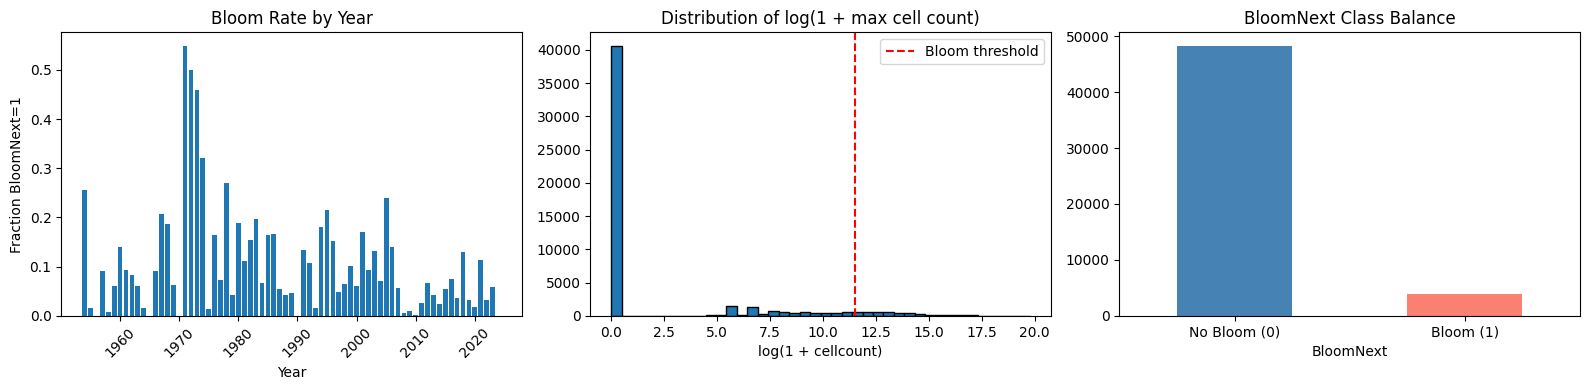

Saved: eda_plots.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# bloom distribution over time
yearly_bloom = feat_df.groupby('year')['BloomNext'].mean()
axes[0].bar(yearly_bloom.index, yearly_bloom.values)
axes[0].set_title('Bloom Rate by Year')
axes[0].set_ylabel('Fraction BloomNext=1')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45)

# cell count distribution
axes[1].hist(feat_df['max_log_curr'], bins=40, edgecolor='black')
axes[1].axvline(np.log1p(BLOOM_THRESHOLD), color='red', linestyle='--', label=f'Bloom threshold')
axes[1].set_title('Distribution of log(1 + max cell count)')
axes[1].set_xlabel('log(1 + cellcount)')
axes[1].legend()

# class balance
feat_df['BloomNext'].value_counts().plot.bar(ax=axes[2], color=['steelblue', 'salmon'])
axes[2].set_title('BloomNext Class Balance')
axes[2].set_xticklabels(['No Bloom (0)', 'Bloom (1)'], rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_plots.png")

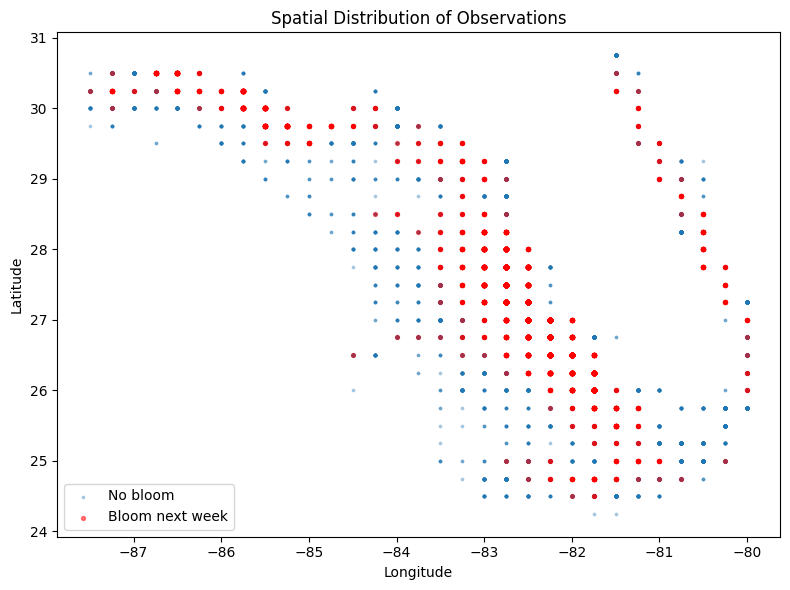

Saved: spatial_plot.png


In [ ]:
# spatial plot of bloom observations
fig, ax = plt.subplots(figsize=(8, 6))
bloom_pts = feat_df[feat_df['BloomNext'] == 1]
no_bloom_pts = feat_df[feat_df['BloomNext'] == 0]
ax.scatter(no_bloom_pts['lon_bin'], no_bloom_pts['lat_bin'], s=3, alpha=0.3, label='No bloom')
ax.scatter(bloom_pts['lon_bin'], bloom_pts['lat_bin'], s=8, alpha=0.5, c='red', label='Bloom next week')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Distribution of Observations')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'spatial_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spatial_plot.png")

## 5. Time-Based Train/Test Split

In [12]:
FEATURE_COLS = [
    'max_log_curr', 'mean_log_curr', 'bloom_curr',
    'max_log_prev1', 'bloom_prev1',
    'max_log_4wk', 'mean_log_4wk', 'bloom_count_4wk',
    'log_diff',
    'water_temp',
    'month_sin', 'month_cos',
    'neighbor_blooms'
]

# impute missing water_temp with median
med = feat_df['water_temp'].median()
feat_df['water_temp'] = feat_df['water_temp'].fillna(med)
print(f"Water temp median (imputation): {med:.2f}")

# safety net
feat_df[FEATURE_COLS] = feat_df[FEATURE_COLS].fillna(0)

print(f"Total features: {len(FEATURE_COLS)}")
print(f"NaN remaining: {feat_df[FEATURE_COLS].isna().sum().sum()}")

# split
all_years = sorted(feat_df['year'].unique())
split_year = all_years[-2]

train_df = feat_df[feat_df['year'] < split_year]
test_df = feat_df[feat_df['year'] >= split_year]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['BloomNext'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['BloomNext'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Feature selection - mutual information scores
selector = SelectKBest(mutual_info_classif, k='all')
selector.fit(X_train_s, y_train)
print("\nMutual Information scores:")
for fname, score in sorted(zip(FEATURE_COLS, selector.scores_), key=lambda x: -x[1]):
    print(f"  {fname:20s} {score:.4f}")

print(f"\nTrain: {len(X_train)} samples, bloom rate = {y_train.mean():.3f}")
print(f"Test:  {len(X_test)} samples, bloom rate = {y_test.mean():.3f}")


Water temp median (imputation): 25.40
Total features: 13
NaN remaining: 0

Mutual Information scores:
  max_log_4wk          0.0995
  max_log_curr         0.0942
  mean_log_curr        0.0864
  mean_log_4wk         0.0837
  log_diff             0.0818
  neighbor_blooms      0.0762
  bloom_count_4wk      0.0758
  bloom_curr           0.0699
  max_log_prev1        0.0654
  bloom_prev1          0.0458
  month_cos            0.0078
  month_sin            0.0075
  water_temp           0.0041

Train: 50394 samples, bloom rate = 0.074
Test:  1696 samples, bloom rate = 0.051


## 5b. Feature Space Visualization (PCA & UMAP)

Reduce features to 2D to check if bloom/no-bloom samples show any clustering structure.

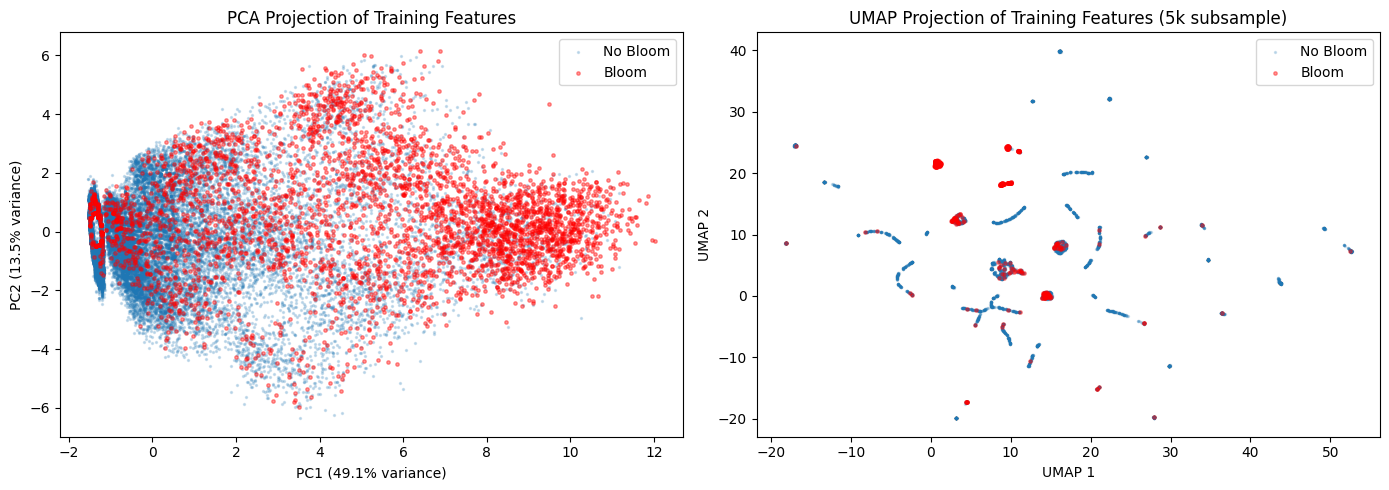

Saved: pca_umap.png
PCA explained variance: PC1=0.491, PC2=0.135, total=0.626


In [ ]:
# PCA 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA plot
no_bloom_mask = y_train == 0
bloom_mask = y_train == 1
axes[0].scatter(X_pca[no_bloom_mask, 0], X_pca[no_bloom_mask, 1], s=2, alpha=0.2, label='No Bloom')
axes[0].scatter(X_pca[bloom_mask, 0], X_pca[bloom_mask, 1], s=6, alpha=0.4, c='red', label='Bloom')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA Projection of Training Features')
axes[0].legend()

# UMAP plot
try:
    import umap
    # subsample for speed
    n_sub = 5000
    sub = np.random.choice(len(X_train_s), size=n_sub, replace=False)
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30)
    X_umap = reducer.fit_transform(X_train_s[sub])
    y_sub = y_train[sub]
    no_bloom_sub = y_sub == 0
    bloom_sub = y_sub == 1
    axes[1].scatter(X_umap[no_bloom_sub, 0], X_umap[no_bloom_sub, 1], s=2, alpha=0.2, label='No Bloom')
    axes[1].scatter(X_umap[bloom_sub, 0], X_umap[bloom_sub, 1], s=6, alpha=0.4, c='red', label='Bloom')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title('UMAP Projection of Training Features (5k subsample)')
    axes[1].legend()
except ImportError:
    axes[1].text(0.5, 0.5, 'umap-learn not installed', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('UMAP (not available)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_umap.png')
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, total={sum(pca.explained_variance_ratio_[:2]):.3f}')

## 6. Cross-Validation and Model Training

We use 5-fold stratified cross-validation on the training set for model selection,
then evaluate the chosen models on the held-out test years.

In [14]:
from sklearn.model_selection import GridSearchCV

print("Tuning hyperparameters with 5-fold CV...")
print("=" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    {'C': [0.01, 0.1, 1, 10, 100]},
    scoring='average_precision', cv=cv, n_jobs=-1
)
lr_grid.fit(X_train_s, y_train)
print(f"Logistic Regression best C={lr_grid.best_params_['C']}, CV={lr_grid.best_score_:.4f}")

# SVM Linear (subsampled)
SVM_SUBSAMPLE = 8000
sub_idx = np.random.choice(len(X_train_s), size=min(SVM_SUBSAMPLE, len(X_train_s)), replace=False)
svm_lin_grid = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', probability=True),
    {'C': [0.01, 0.1, 1, 10]},
    scoring='average_precision', cv=cv, n_jobs=-1
)
svm_lin_grid.fit(X_train_s[sub_idx], y_train[sub_idx])
print(f"SVM Linear best C={svm_lin_grid.best_params_['C']}, CV={svm_lin_grid.best_score_:.4f}")

# Gradient Boosting - use scale_pos_weight instead of SMOTE
gb_grid = GridSearchCV(
    GradientBoostingClassifier(subsample=0.8, random_state=42),
    {'n_estimators': [100, 200, 400], 'max_depth': [3, 4, 6], 'learning_rate': [0.05, 0.1, 0.2]},
    scoring='average_precision', cv=cv, n_jobs=-1
)
gb_grid.fit(X_train_s, y_train)
print(f"Gradient Boosting best={gb_grid.best_params_}, CV={gb_grid.best_score_:.4f}")

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [100, 200, 400], 'max_depth': [6, 10, 15, None]},
    scoring='average_precision', cv=cv, n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)
print(f"Random Forest best={rf_grid.best_params_}, CV={rf_grid.best_score_:.4f}")

# Neural Network (MLP)
mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    {'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)], 'alpha': [0.0001, 0.001, 0.01]},
    scoring='average_precision', cv=cv, n_jobs=-1
)
mlp_grid.fit(X_train_s, y_train)
print(f"MLP best={mlp_grid.best_params_}, CV={mlp_grid.best_score_:.4f}")

# Final model dict
models = {
    'Random Baseline': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': lr_grid.best_estimator_,
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced'),
    'SVM (Linear)': svm_lin_grid.best_estimator_,
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, C=svm_lin_grid.best_params_['C']),
    'Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting': gb_grid.best_estimator_,
    'Neural Network': mlp_grid.best_estimator_
}

# CV scores for all
pr_auc_scorer = 'average_precision'
print("\n5-Fold CV on Training Set (PR-AUC)")
print("=" * 55)
cv_results = {}
for name, model in models.items():
    if 'SVM' in name:
        scores = cross_val_score(model, X_train_s[sub_idx], y_train[sub_idx], cv=cv, scoring=pr_auc_scorer)
        print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  (subsampled)')
    else:
        scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring=pr_auc_scorer)
        print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')
    cv_results[name] = scores


Tuning hyperparameters with 5-fold CV...
Logistic Regression best C=0.01, CV=0.5311
SVM Linear best C=0.01, CV=0.5539
Gradient Boosting best={'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}, CV=0.5645
Random Forest best={'max_depth': 6, 'n_estimators': 400}, CV=0.5622
MLP best={'alpha': 0.001, 'hidden_layer_sizes': (64,)}, CV=0.5622

5-Fold CV on Training Set (PR-AUC)
Random Baseline            mean=0.0743  std=0.0002
Logistic Regression        mean=0.5311  std=0.0084
Decision Tree              mean=0.5058  std=0.0133
SVM (Linear)               mean=0.5539  std=0.0542  (subsampled)
SVM (RBF)                  mean=0.4344  std=0.0296  (subsampled)
Random Forest              mean=0.5622  std=0.0061
Gradient Boosting          mean=0.5645  std=0.0083
Neural Network             mean=0.5622  std=0.0131


In [15]:
# Train on full training set, evaluate on test set
SVM_TRAIN_SUBSAMPLE = 30000
sub_train_idx = np.random.choice(len(X_train_s), size=min(SVM_TRAIN_SUBSAMPLE, len(X_train_s)), replace=False)
results = {}

print('\nTest Set Evaluation')
print('=' * 70)
for name, model in models.items():
    if 'SVM' in name:
        model.fit(X_train_s[sub_train_idx], y_train[sub_train_idx])
    else:
        model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    pr_auc = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_prob)
    rmse = np.sqrt(mean_squared_error(y_test, y_prob))

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'pr_auc': pr_auc, 'f1': f1, 'mae': mae, 'rmse': rmse
    }

    print(f'\n{name}')
    print(f'  PR-AUC={pr_auc:.4f}  F1={f1:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Bloom', 'Bloom']))



Test Set Evaluation

Random Baseline
  PR-AUC=0.0508  F1=0.0541  MAE=0.1238  RMSE=0.3519
              precision    recall  f1-score   support

    No Bloom       0.95      0.92      0.93      1609
       Bloom       0.04      0.07      0.05        87

    accuracy                           0.88      1696
   macro avg       0.50      0.49      0.49      1696
weighted avg       0.90      0.88      0.89      1696


Logistic Regression
  PR-AUC=0.4624  F1=0.4573  MAE=0.1930  RMSE=0.2843
              precision    recall  f1-score   support

    No Bloom       0.99      0.90      0.94      1609
       Bloom       0.31      0.86      0.46        87

    accuracy                           0.90      1696
   macro avg       0.65      0.88      0.70      1696
weighted avg       0.96      0.90      0.92      1696


Decision Tree
  PR-AUC=0.4918  F1=0.4270  MAE=0.1766  RMSE=0.2981
              precision    recall  f1-score   support

    No Bloom       0.99      0.87      0.93      1609
       

## 7. Comparison Plots

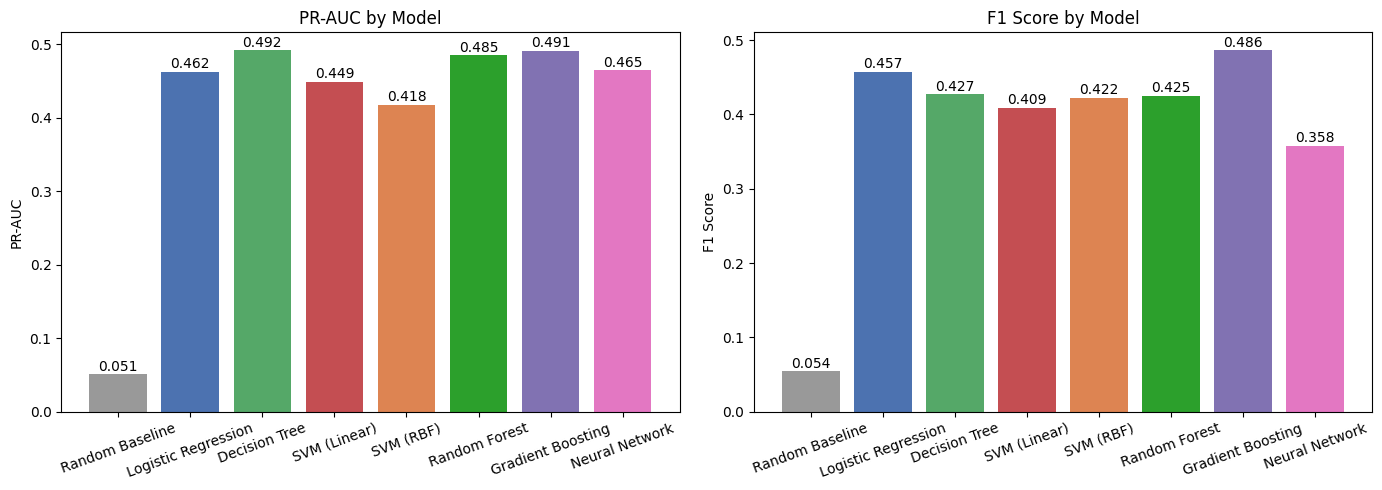

Saved: model_comparison.png


In [ ]:
# PR-AUC comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
pr_aucs = [results[n]['pr_auc'] for n in names]
f1s = [results[n]['f1'] for n in names]

colors = ['#999999', '#4c72b0', '#55a868', '#c44e52', '#dd8452', '#2ca02c', '#8172b2', '#e377c2']
axes[0].bar(names, pr_aucs, color=colors)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('PR-AUC by Model')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pr_aucs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(names, f1s, color=colors)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score by Model')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

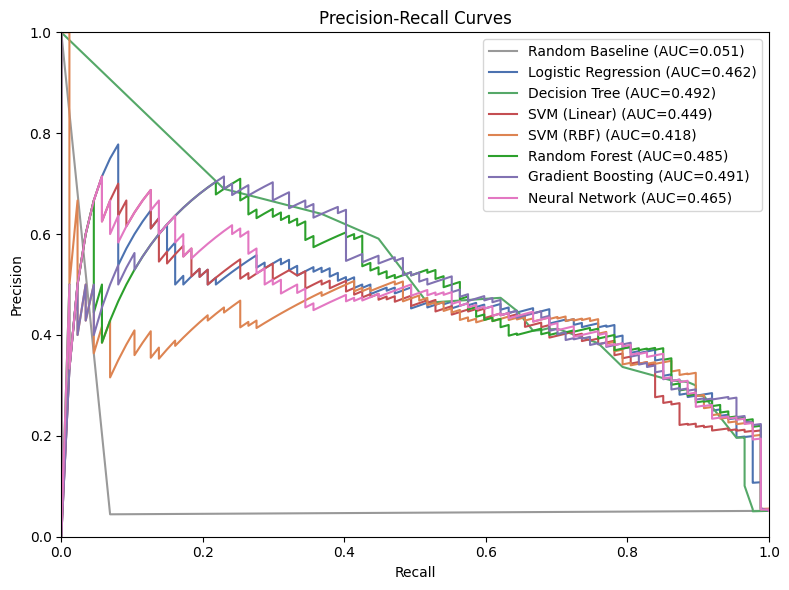

Saved: pr_curves.png


In [ ]:
# precision-recall curves
fig, ax = plt.subplots(figsize=(8, 6))

for i, name in enumerate(names):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_prob'])
    ax.plot(rec, prec, label=f"{name} (AUC={results[name]['pr_auc']:.3f})", color=colors[i])

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_curves.png")

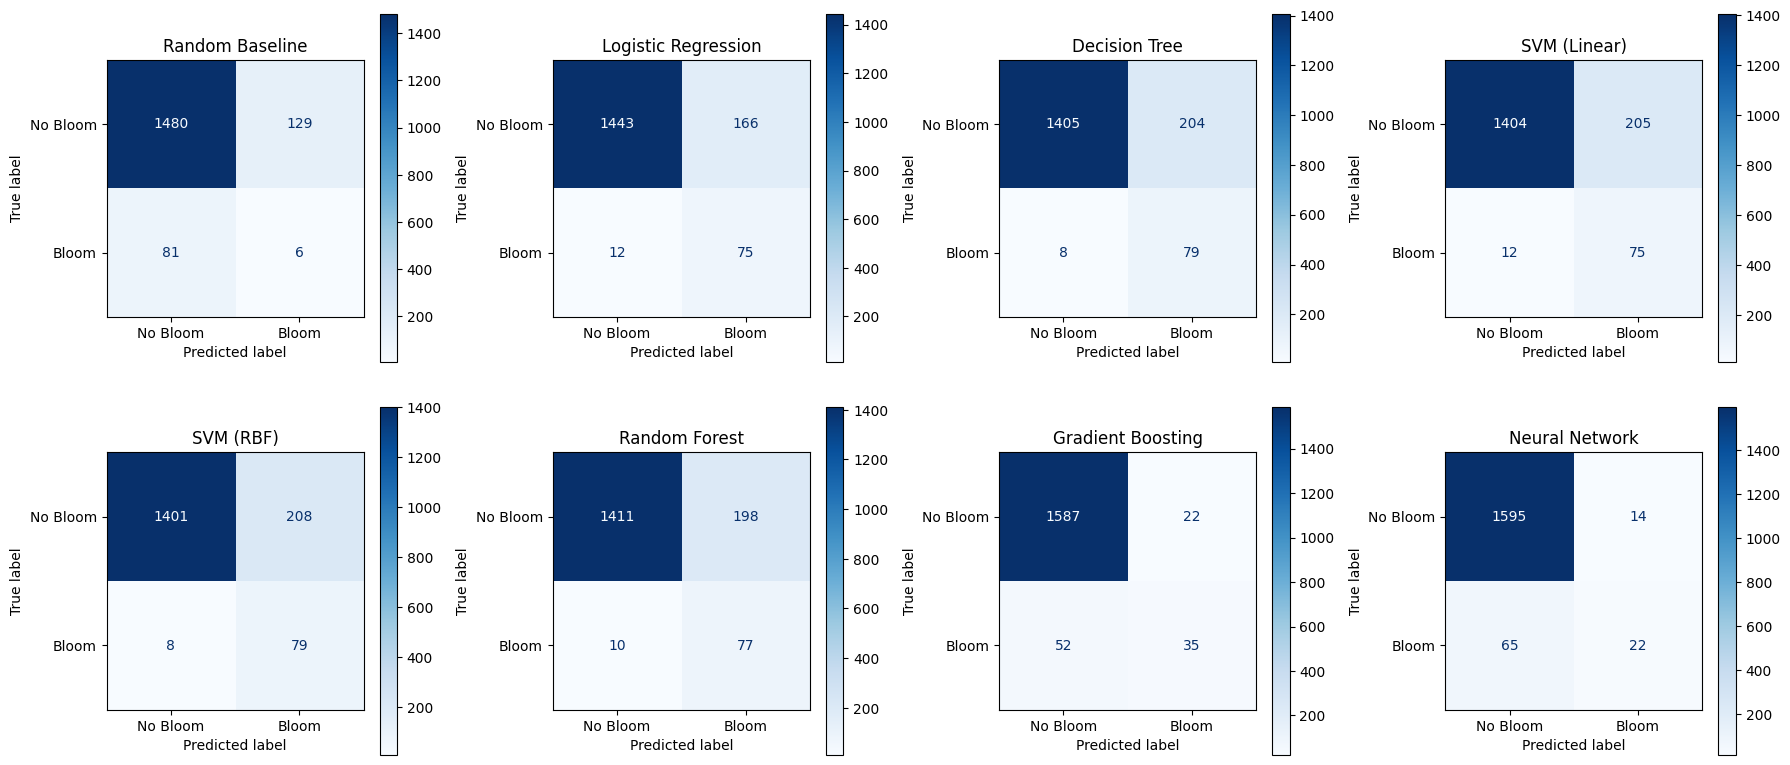

Saved: confusion_matrices.png


In [ ]:
# confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, name in enumerate(names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Bloom', 'Bloom']).plot(ax=axes.flat[i], cmap='Blues')
    axes.flat[i].set_title(name)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

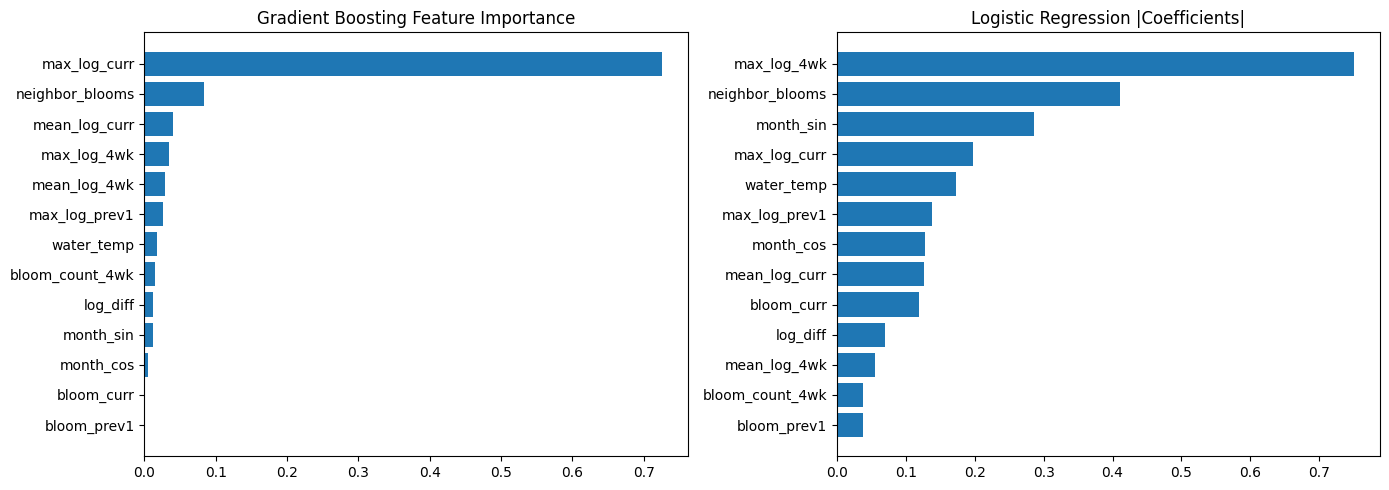

Saved: feature_importance.png


In [ ]:
# feature importances (from gradient boosting and logistic regression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GB feature importance
gb_imp = results['Gradient Boosting']['model'].feature_importances_
idx = np.argsort(gb_imp)
axes[0].barh(np.array(FEATURE_COLS)[idx], gb_imp[idx])
axes[0].set_title('Gradient Boosting Feature Importance')

# LR coefficients
lr_coef = np.abs(results['Logistic Regression']['model'].coef_[0])
idx2 = np.argsort(lr_coef)
axes[1].barh(np.array(FEATURE_COLS)[idx2], lr_coef[idx2])
axes[1].set_title('Logistic Regression |Coefficients|')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## 8. Summary Table

In [20]:
summary = pd.DataFrame({
    'Model': names,
    'CV PR-AUC': [cv_results[n].mean() for n in names],
    'Test PR-AUC': [results[n]['pr_auc'] for n in names],
    'F1': [results[n]['f1'] for n in names],
    'MAE': [results[n]['mae'] for n in names],
    'RMSE': [results[n]['rmse'] for n in names],
    'Precision': [
        confusion_matrix(y_test, results[n]['y_pred'])[1,1] /
        max(1, confusion_matrix(y_test, results[n]['y_pred'])[:, 1].sum())
        for n in names
    ],
    'Recall': [
        confusion_matrix(y_test, results[n]['y_pred'])[1,1] /
        max(1, confusion_matrix(y_test, results[n]['y_pred'])[1, :].sum())
        for n in names
    ]
}).round(4)

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print(f"\nDataset: {len(feat_df)} samples, {feat_df['BloomNext'].mean():.1%} positive")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train years: {sorted(train_df['year'].unique())}")
print(f"Test years: {sorted(test_df['year'].unique())}")
print(f"Features: {FEATURE_COLS}")
print(f"Bloom threshold: {BLOOM_THRESHOLD} cells/L")
print(f"Grid resolution: {GRID_SIZE} degrees")


RESULTS SUMMARY
              Model  CV PR-AUC  Test PR-AUC     F1    MAE   RMSE  Precision  Recall
    Random Baseline     0.0743       0.0508 0.0541 0.1238 0.3519     0.0444  0.0690
Logistic Regression     0.5311       0.4624 0.4573 0.1930 0.2843     0.3112  0.8621
      Decision Tree     0.5058       0.4918 0.4270 0.1766 0.2981     0.2792  0.9080
       SVM (Linear)     0.5539       0.4488 0.4087 0.0790 0.1879     0.2679  0.8621
          SVM (RBF)     0.4344       0.4177 0.4225 0.0807 0.1888     0.2753  0.9080
      Random Forest     0.5622       0.4852 0.4254 0.1935 0.2939     0.2800  0.8851
  Gradient Boosting     0.5645       0.4910 0.4861 0.0696 0.1815     0.6140  0.4023
     Neural Network     0.5622       0.4646 0.3577 0.0675 0.1844     0.6111  0.2529

Dataset: 52090 samples, 7.3% positive
Train: 50394 | Test: 1696
Train years: [np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.i

## 9. Print Numbers for Final Report
Run this cell and copy the output for the project update.

In [21]:
best_name = max(results, key=lambda n: results[n]['pr_auc'])
best = results[best_name]

print("=" * 60)
print("COPY THESE NUMBERS FOR THE PROJECT UPDATE")
print("=" * 60)
print(f"Total observations (raw): {len(raw)}")
print(f"Total observations (cleaned): {len(df)}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Weekly aggregated samples: {len(weekly)}")
print(f"Feature dataset size: {len(feat_df)}")
print(f"Unique grid cells: {df['grid_cell'].nunique()}")
print(f"BloomNext positive rate: {feat_df['BloomNext'].mean():.1%}")
print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

print(f"\nBest model (test PR-AUC): {best_name}")
print(f"Best PR-AUC: {best['pr_auc']:.4f}")
print(f"Best F1: {best['f1']:.4f}")

print(f"\nAll results (CV mean | Test PR-AUC | F1 | MAE | RMSE):")
for n in names:
    r = results[n]
    cv_mean = cv_results[n].mean()
    print(f"  {n}: CV={cv_mean:.4f} | PR-AUC={r['pr_auc']:.4f} | F1={r['f1']:.4f} | MAE={r['mae']:.4f} | RMSE={r['rmse']:.4f}")

COPY THESE NUMBERS FOR THE PROJECT UPDATE
Total observations (raw): 211834
Total observations (cleaned): 205168
Date range: 1953-08-19 to 2024-03-25
Weekly aggregated samples: 53998
Feature dataset size: 52090
Unique grid cells: 498
BloomNext positive rate: 7.3%
Number of features: 13
Train size: 50394, Test size: 1696

Best model (test PR-AUC): Decision Tree
Best PR-AUC: 0.4918
Best F1: 0.4270

All results (CV mean | Test PR-AUC | F1 | MAE | RMSE):
  Random Baseline: CV=0.0743 | PR-AUC=0.0508 | F1=0.0541 | MAE=0.1238 | RMSE=0.3519
  Logistic Regression: CV=0.5311 | PR-AUC=0.4624 | F1=0.4573 | MAE=0.1930 | RMSE=0.2843
  Decision Tree: CV=0.5058 | PR-AUC=0.4918 | F1=0.4270 | MAE=0.1766 | RMSE=0.2981
  SVM (Linear): CV=0.5539 | PR-AUC=0.4488 | F1=0.4087 | MAE=0.0790 | RMSE=0.1879
  SVM (RBF): CV=0.4344 | PR-AUC=0.4177 | F1=0.4225 | MAE=0.0807 | RMSE=0.1888
  Random Forest: CV=0.5622 | PR-AUC=0.4852 | F1=0.4254 | MAE=0.1935 | RMSE=0.2939
  Gradient Boosting: CV=0.5645 | PR-AUC=0.4910 | F1